In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os
warnings.filterwarnings("ignore")

In [12]:
TRAIN_PATH    = '/content/sales_churn_train.csv'
COOLERS_PATH  = '/content/Coolers.csv'
CLIENTES_PATH = '/content/Clientes.csv'

In [13]:
PINK   = "#E91E8C"
RED    = "#C0392B"
DARK   = "#1A1A2E"
GRAY   = "#8CA0B3"
LIGHT  = "#F7F0F5"
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "#FAFAFA",
                     "axes.spines.top": False, "axes.spines.right": False})

def save(fig, name):
    plt.show()

In [8]:
train    = pd.read_csv(TRAIN_PATH).sort_values(["customer_id", "calmonth"])
coolers  = pd.read_csv(COOLERS_PATH).sort_values(["customer_id", "calmonth"])
clientes = pd.read_csv(CLIENTES_PATH)

# Train con clientes
train = train.merge(clientes, on="customer_id", how="left")

# Una fila por cliente (último estado)
cust = train.groupby("customer_id").agg(
    target          = ("target", "max"),
    n_meses         = ("calmonth", "count"),
    mean_cajas      = ("uni_boxes_sold_m", "mean"),
    last_cajas      = ("uni_boxes_sold_m", "last"),
    max_cajas       = ("uni_boxes_sold_m", "max"),
    mean_txns       = ("num_transacciones", "mean"),
    last_txns       = ("num_transacciones", "last"),
    territory       = ("territory_d", "first"),
    subchannel      = ("comercial_subchannel_d", "first"),
    size            = ("rtm_customer_size_d", "first"),
).reset_index()

print(f"  Train:    {len(train):,} filas · {train['customer_id'].nunique():,} clientes")
print(f"  Coolers:  {len(coolers):,} filas · {coolers['customer_id'].nunique():,} clientes")
print(f"  Clientes: {len(clientes):,} registros")
print(f"  Tasa churn global: {cust['target'].mean():.2%}")

  Train:    5,030,534 filas · 241,805 clientes
  Coolers:  4,636,676 filas · 208,024 clientes
  Clientes: 371,727 registros
  Tasa churn global: 17.95%


## Distribución de Churn

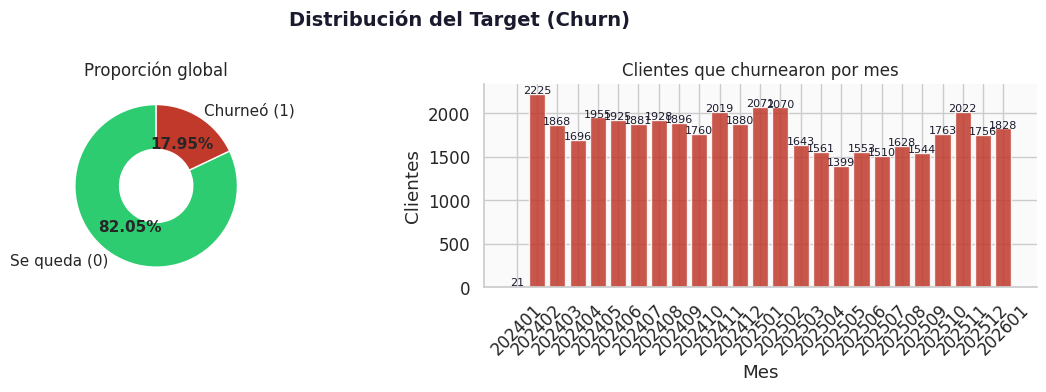

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Distribución del Target (Churn)", fontsize=14, fontweight="bold", color=DARK)

# Donut
labels = ["Se queda (0)", "Churneó (1)"]
vals   = cust["target"].value_counts().sort_index().values
colors = ["#2ECC71", RED]
wedges, texts, autotexts = axes[0].pie(
    vals, labels=labels, colors=colors, autopct="%1.2f%%",
    startangle=90, wedgeprops=dict(width=0.55),
    textprops={"fontsize": 11}
)
for at in autotexts: at.set_fontweight("bold")
axes[0].set_title("Proporción global", fontsize=12)

# Churn por mes
churn_mes = train[train["target"] == 1].groupby("calmonth")["customer_id"].nunique()
axes[1].bar(churn_mes.index.astype(str), churn_mes.values, color=RED, alpha=0.85)
axes[1].set_title("Clientes que churnearon por mes", fontsize=12)
axes[1].set_xlabel("Mes"); axes[1].set_ylabel("Clientes")
axes[1].tick_params(axis="x", rotation=45)
for i, v in enumerate(churn_mes.values):
    axes[1].text(i, v + 1, str(v), ha="center", fontsize=8, color=DARK)

plt.tight_layout()
save(fig, "01_churn_distribucion")

## Volumen de Ventas

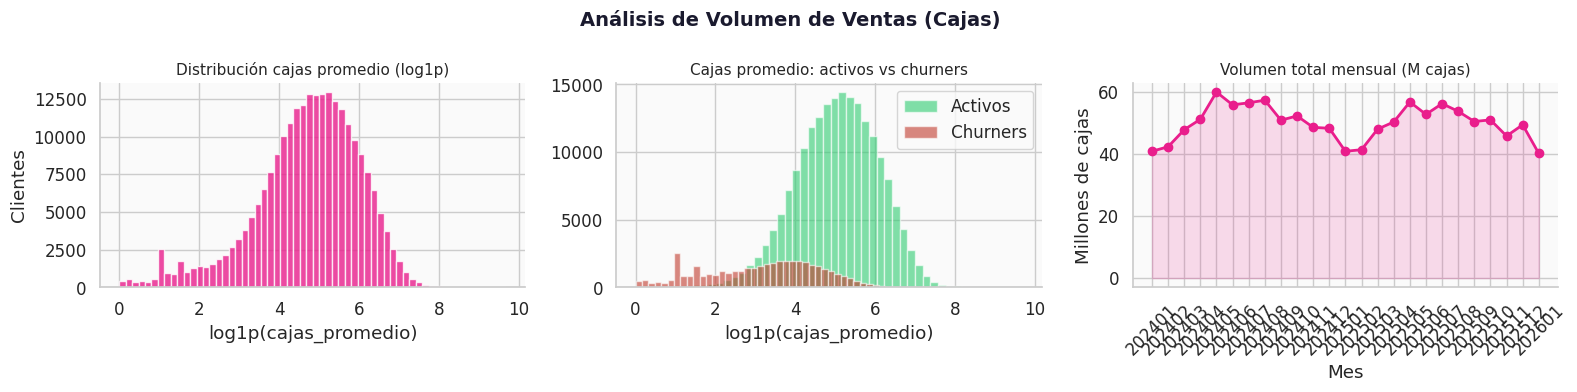

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Análisis de Volumen de Ventas (Cajas)", fontsize=14, fontweight="bold", color=DARK)

# Histograma log-scale
ax = axes[0]
vals_log = np.log1p(cust.loc[cust["mean_cajas"] > 0, "mean_cajas"])
ax.hist(vals_log, bins=60, color=PINK, alpha=0.8, edgecolor="white")
ax.set_title("Distribución cajas promedio (log1p)", fontsize=11)
ax.set_xlabel("log1p(cajas_promedio)"); ax.set_ylabel("Clientes")

# Cajas por grupo: churners vs activos
ax = axes[1]
for t, label, color in [(0, "Activos", "#2ECC71"), (1, "Churners", RED)]:
    data = np.log1p(cust.loc[cust["target"] == t, "mean_cajas"].clip(0))
    ax.hist(data, bins=50, alpha=0.6, label=label, color=color, edgecolor="white")
ax.set_title("Cajas promedio: activos vs churners", fontsize=11)
ax.set_xlabel("log1p(cajas_promedio)"); ax.legend()

# Evolución mensual total
ax = axes[2]
vol_mes = train.groupby("calmonth")["uni_boxes_sold_m"].sum() / 1e6
ax.plot(vol_mes.index.astype(str), vol_mes.values, color=PINK, marker="o", linewidth=2)
ax.fill_between(range(len(vol_mes)), vol_mes.values, alpha=0.15, color=PINK)
ax.set_title("Volumen total mensual (M cajas)", fontsize=11)
ax.set_xlabel("Mes"); ax.set_ylabel("Millones de cajas")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
save(fig, "02_ventas_volumen")

## Transacciones

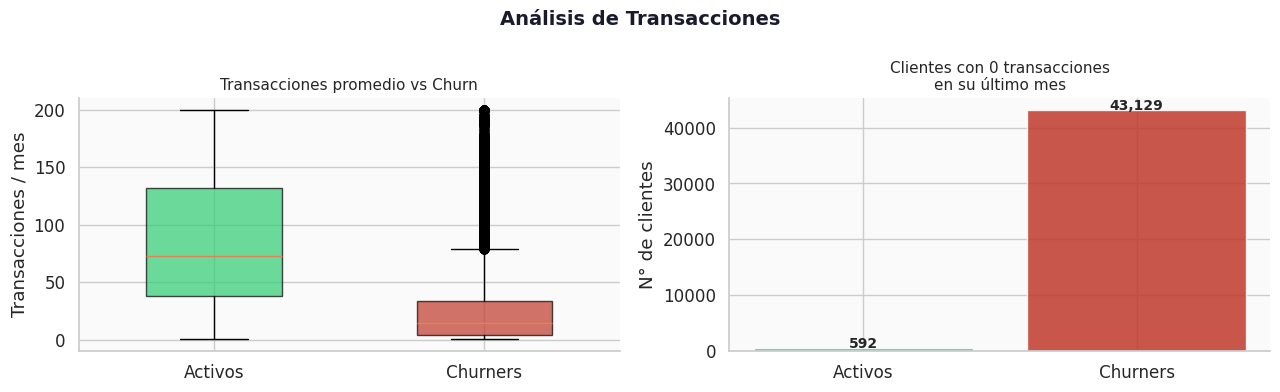

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Análisis de Transacciones", fontsize=14, fontweight="bold", color=DARK)

# Boxplot txns por target
ax = axes[0]
data_activos  = cust.loc[cust["target"] == 0, "mean_txns"].clip(0, 200)
data_churners = cust.loc[cust["target"] == 1, "mean_txns"].clip(0, 200)
bp = ax.boxplot([data_activos, data_churners], patch_artist=True,
                labels=["Activos", "Churners"], widths=0.5)
for patch, color in zip(bp["boxes"], ["#2ECC71", RED]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_title("Transacciones promedio vs Churn", fontsize=11)
ax.set_ylabel("Transacciones / mes")

# Clientes con 0 transacciones el último mes
ax = axes[1]
cero_txns = cust.groupby("target").apply(
    lambda df: (df["last_txns"] == 0).sum()
).reset_index(name="n_cero")
cero_txns["label"] = cero_txns["target"].map({0: "Activos", 1: "Churners"})
bars = ax.bar(cero_txns["label"], cero_txns["n_cero"],
              color=["#2ECC71", RED], alpha=0.85, edgecolor="white")
ax.set_title("Clientes con 0 transacciones\nen su último mes", fontsize=11)
ax.set_ylabel("N° de clientes")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{int(bar.get_height()):,}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
save(fig, "03_transacciones")

## Análisis por Territorio

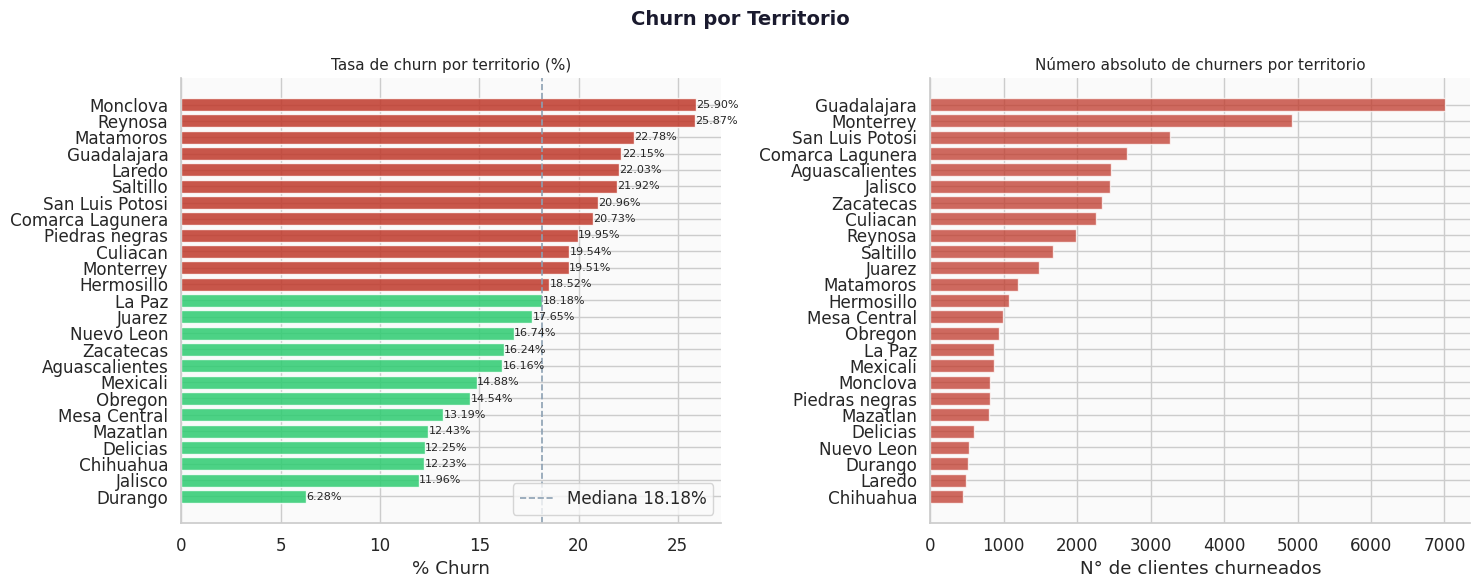

In [17]:
churn_terr = (
    cust.groupby("territory")["target"]
        .agg(["mean", "sum", "count"])
        .rename(columns={"mean": "tasa_churn", "sum": "n_churn", "count": "n_total"})
        .sort_values("tasa_churn", ascending=True)
        .reset_index()
)
churn_terr["tasa_pct"] = churn_terr["tasa_churn"] * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Churn por Territorio", fontsize=14, fontweight="bold", color=DARK)

# Tasa de churn por territorio
ax = axes[0]
colors_bar = [RED if v > churn_terr["tasa_pct"].median() else "#2ECC71"
              for v in churn_terr["tasa_pct"]]
bars = ax.barh(churn_terr["territory"], churn_terr["tasa_pct"],
               color=colors_bar, alpha=0.85, edgecolor="white")
ax.axvline(churn_terr["tasa_pct"].median(), color=GRAY, linestyle="--",
           linewidth=1.2, label=f"Mediana {churn_terr['tasa_pct'].median():.2f}%")
ax.set_title("Tasa de churn por territorio (%)", fontsize=11)
ax.set_xlabel("% Churn"); ax.legend()
for i, (_, row) in enumerate(churn_terr.iterrows()):
    ax.text(row["tasa_pct"] + 0.02, i, f"{row['tasa_pct']:.2f}%",
            va="center", fontsize=8)

# Volumen absoluto de churners
ax = axes[1]
top_abs = churn_terr.sort_values("n_churn", ascending=True)
ax.barh(top_abs["territory"], top_abs["n_churn"], color=RED, alpha=0.75, edgecolor="white")
ax.set_title("Número absoluto de churners por territorio", fontsize=11)
ax.set_xlabel("N° de clientes churneados")

plt.tight_layout()
save(fig, "04_territorio")

## Análisis por subcanal y tamaño

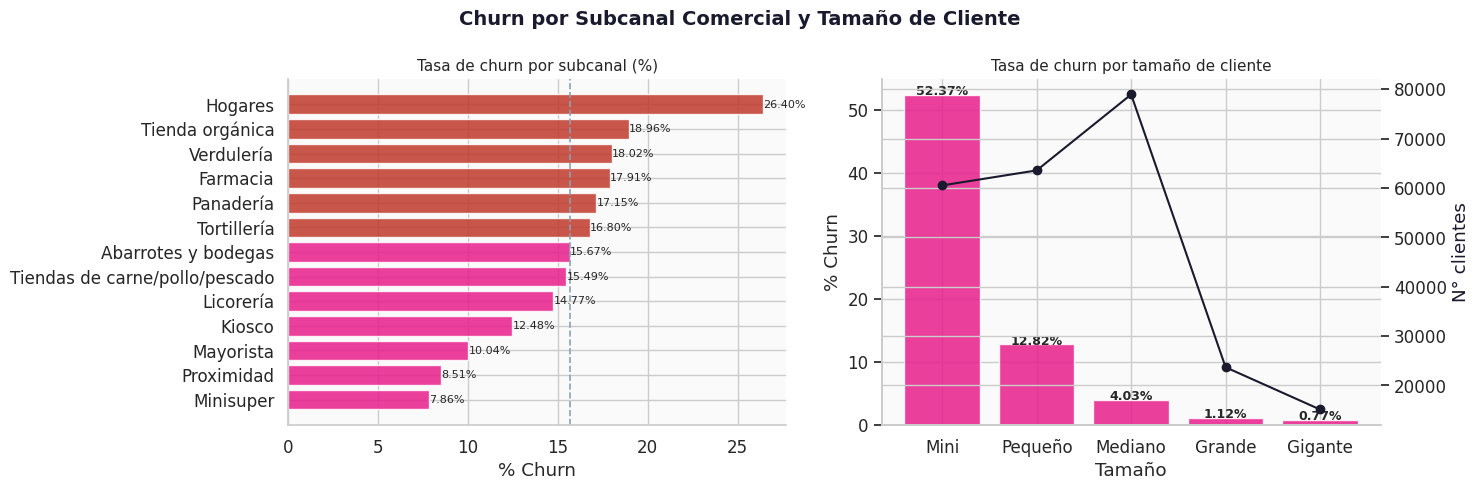

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Churn por Subcanal Comercial y Tamaño de Cliente",
             fontsize=14, fontweight="bold", color=DARK)

# Subcanal
churn_sub = (
    cust.groupby("subchannel")["target"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "tasa", "count": "n"})
        .sort_values("tasa", ascending=True)
        .reset_index()
)
ax = axes[0]
colors_sub = [RED if v > churn_sub["tasa"].median() else PINK
              for v in churn_sub["tasa"]]
ax.barh(churn_sub["subchannel"], churn_sub["tasa"] * 100,
        color=colors_sub, alpha=0.85, edgecolor="white")
ax.axvline(churn_sub["tasa"].median() * 100, color=GRAY, linestyle="--", linewidth=1.2)
ax.set_title("Tasa de churn por subcanal (%)", fontsize=11)
ax.set_xlabel("% Churn")
for i, (_, row) in enumerate(churn_sub.iterrows()):
    ax.text(row["tasa"]*100 + 0.01, i, f"{row['tasa']*100:.2f}%", va="center", fontsize=8)

# Tamaño
size_order = ["Mini", "Pequeño", "Mediano", "Grande", "Gigante", "NA"]
churn_size = (
    cust.groupby("size")["target"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "tasa", "count": "n"})
        .reindex(size_order)
        .dropna()
        .reset_index()
)
ax = axes[1]
ax.bar(churn_size["size"], churn_size["tasa"] * 100,
       color=PINK, alpha=0.85, edgecolor="white")
ax2 = ax.twinx()
ax2.plot(churn_size["size"], churn_size["n"],
         color=DARK, marker="o", linewidth=1.5, label="N° clientes")
ax2.set_ylabel("N° clientes", color=DARK)
ax.set_title("Tasa de churn por tamaño de cliente", fontsize=11)
ax.set_xlabel("Tamaño"); ax.set_ylabel("% Churn")
for i, (_, row) in enumerate(churn_size.iterrows()):
    ax.text(i, row["tasa"]*100 + 0.02, f"{row['tasa']*100:.2f}%",
            ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
save(fig, "05_subcanal_tamano")

## Análisis de Coolers

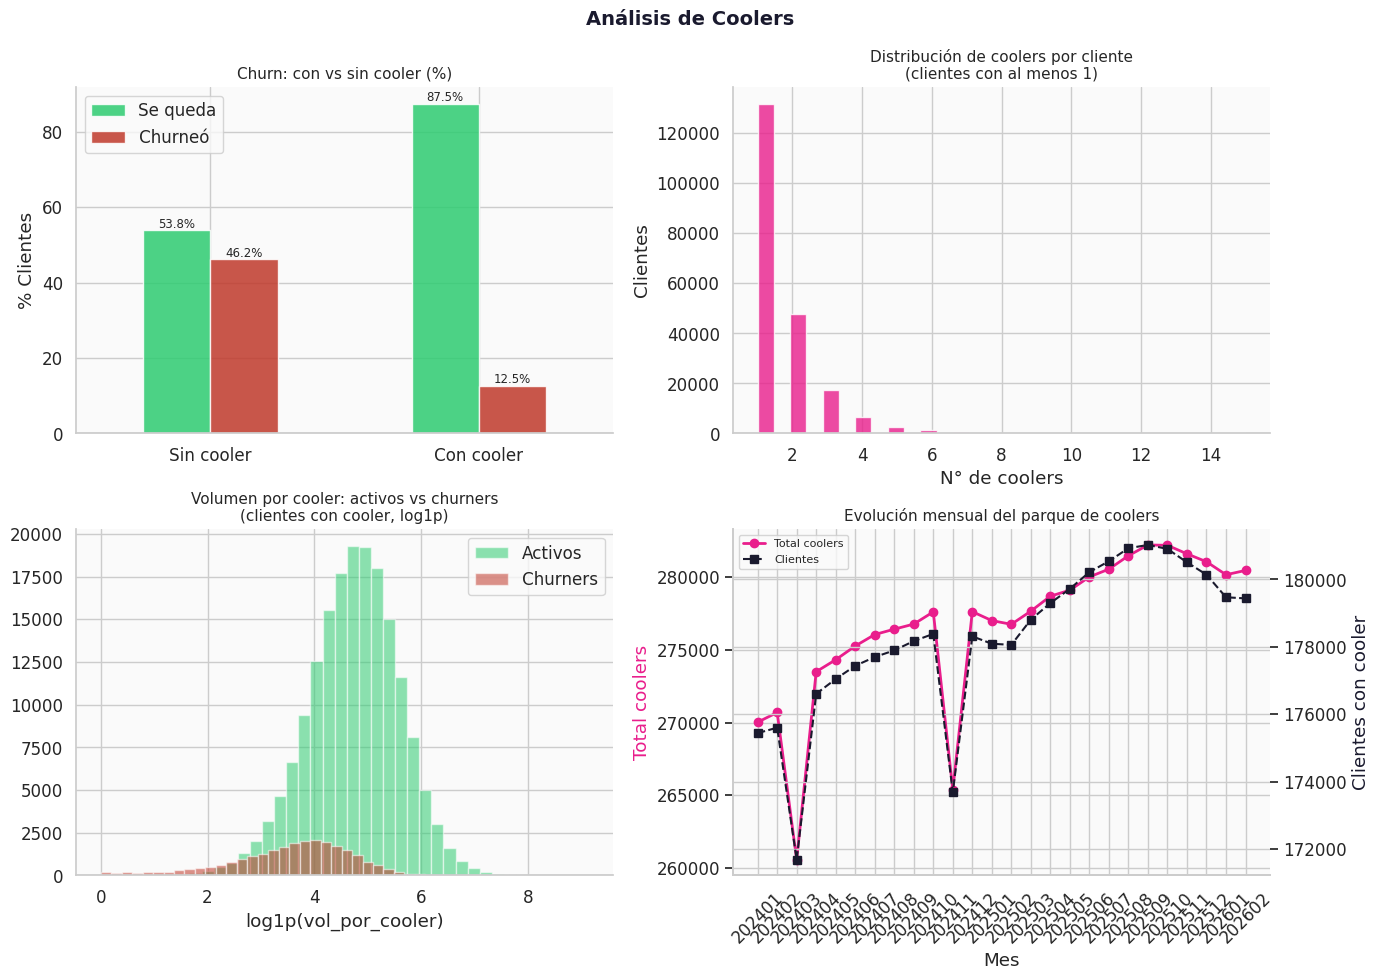

In [19]:
# Estado más reciente de coolers por cliente
cool_latest = (
    coolers.sort_values("calmonth")
           .groupby("customer_id")
           .last()
           .reset_index()[["customer_id", "num_coolers", "num_doors"]]
)
cool_latest["tiene_cooler"] = (cool_latest["num_coolers"] > 0).astype(int)

# Merge con cust
cust_cool = cust.merge(cool_latest, on="customer_id", how="left")
cust_cool["tiene_cooler"] = cust_cool["tiene_cooler"].fillna(0).astype(int)
cust_cool["num_coolers"]  = cust_cool["num_coolers"].fillna(0)
cust_cool["num_doors"]    = cust_cool["num_doors"].fillna(0)
cust_cool["vol_por_cooler"] = cust_cool["mean_cajas"] / (cust_cool["num_coolers"] + 0.1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Análisis de Coolers", fontsize=14, fontweight="bold", color=DARK)

# A — Churn con vs sin cooler
ax = axes[0, 0]
cross = cust_cool.groupby(["tiene_cooler", "target"]).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
cross_pct.index = ["Sin cooler", "Con cooler"]
cross_pct.columns = ["Se queda", "Churneó"]
cross_pct.plot(kind="bar", ax=ax, color=["#2ECC71", RED], alpha=0.85,
               edgecolor="white", rot=0)
ax.set_title("Churn: con vs sin cooler (%)", fontsize=11)
ax.set_ylabel("% Clientes"); ax.legend()
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=8.5)

# B — Distribución de num_coolers
ax = axes[0, 1]
cool_count = coolers.groupby("customer_id")["num_coolers"].max().clip(0, 15)
ax.hist(cool_count[cool_count > 0], bins=30, color=PINK, alpha=0.8, edgecolor="white")
ax.set_title("Distribución de coolers por cliente\n(clientes con al menos 1)", fontsize=11)
ax.set_xlabel("N° de coolers"); ax.set_ylabel("Clientes")

# C — vol_por_cooler: churners vs activos
ax = axes[1, 0]
for t, label, color in [(0, "Activos", "#2ECC71"), (1, "Churners", RED)]:
    data = np.log1p(cust_cool.loc[
        (cust_cool["target"] == t) & (cust_cool["tiene_cooler"] == 1),
        "vol_por_cooler"
    ].clip(0))
    ax.hist(data, bins=40, alpha=0.55, label=label, color=color, edgecolor="white")
ax.set_title("Volumen por cooler: activos vs churners\n(clientes con cooler, log1p)", fontsize=11)
ax.set_xlabel("log1p(vol_por_cooler)"); ax.legend()

# D — Coolers activos por mes
ax = axes[1, 1]
cool_mes = coolers.groupby("calmonth").agg(
    clientes_con_cooler = ("customer_id", "nunique"),
    total_coolers       = ("num_coolers", "sum"),
).reset_index()
ax.plot(cool_mes["calmonth"].astype(str), cool_mes["total_coolers"],
        color=PINK, marker="o", linewidth=2, label="Total coolers")
ax2 = ax.twinx()
ax2.plot(cool_mes["calmonth"].astype(str), cool_mes["clientes_con_cooler"],
         color=DARK, marker="s", linewidth=1.5, linestyle="--", label="Clientes")
ax.set_title("Evolución mensual del parque de coolers", fontsize=11)
ax.set_xlabel("Mes"); ax.set_ylabel("Total coolers", color=PINK)
ax2.set_ylabel("Clientes con cooler", color=DARK)
ax.tick_params(axis="x", rotation=45)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
save(fig, "06_coolers")

## Momentum

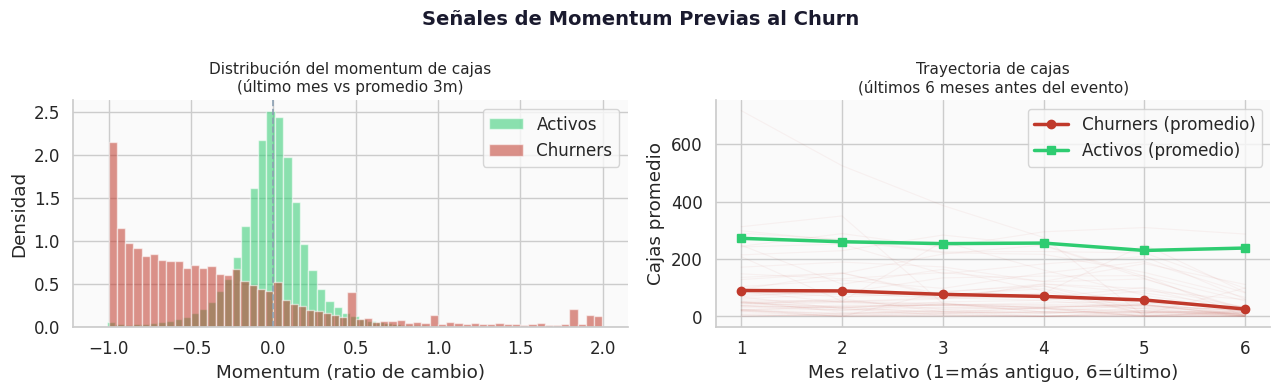

In [21]:
# Para cada cliente calcular tendencia de los últimos 3 meses antes del target
def get_momentum(df):
    rows = []
    for cid, g in df.groupby("customer_id"):
        g = g.sort_values("calmonth")
        target = g["target"].iloc[-1]
        hist   = g.iloc[:-1]
        if len(hist) < 3:
            continue
        cajas = hist["uni_boxes_sold_m"].values
        last3 = cajas[-3:]
        mean3 = last3.mean()
        last  = cajas[-1]
        momentum = (last - mean3) / (mean3 + 0.1)
        rows.append({"customer_id": cid, "target": target, "momentum_3m": momentum})
    return pd.DataFrame(rows)

momentum_df = get_momentum(train)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Señales de Momentum Previas al Churn", fontsize=14, fontweight="bold", color=DARK)

# Histograma momentum
ax = axes[0]
for t, label, color in [(0, "Activos", "#2ECC71"), (1, "Churners", RED)]:
    data = momentum_df.loc[momentum_df["target"] == t, "momentum_3m"].clip(-2, 2)
    ax.hist(data, bins=60, alpha=0.55, label=label, color=color, edgecolor="white", density=True)
ax.axvline(0, color=GRAY, linestyle="--", linewidth=1.2)
ax.set_title("Distribución del momentum de cajas\n(último mes vs promedio 3m)", fontsize=11)
ax.set_xlabel("Momentum (ratio de cambio)"); ax.set_ylabel("Densidad"); ax.legend()

# Evolución de cajas promedio en los N meses antes del churn
ax = axes[1]
ventana = 6
cids_churn = train[train["target"] == 1]["customer_id"].unique()
traces = []
for cid in cids_churn[:300]:
    g = train[train["customer_id"] == cid].sort_values("calmonth")
    hist = g["uni_boxes_sold_m"].values
    if len(hist) >= ventana + 1:
        traces.append(hist[-(ventana+1):-1])

if traces:
    arr = np.array(traces)
    mean_trace = arr.mean(axis=0)
    ax.plot(range(1, ventana+1), mean_trace, color=RED, linewidth=2.5,
            label="Churners (promedio)", marker="o")
    for t in arr[:50]:
        ax.plot(range(1, ventana+1), t, color=RED, alpha=0.05, linewidth=0.8)

# Activos
cids_active = train[train["target"] == 0]["customer_id"].unique()
traces_a = []
for cid in cids_active[:300]:
    g = train[train["customer_id"] == cid].sort_values("calmonth")
    hist = g["uni_boxes_sold_m"].values
    if len(hist) >= ventana + 1:
        traces_a.append(hist[-(ventana+1):-1])

if traces_a:
    arr_a = np.array(traces_a)
    mean_a = arr_a.mean(axis=0)
    ax.plot(range(1, ventana+1), mean_a, color="#2ECC71", linewidth=2.5,
            label="Activos (promedio)", marker="s")

ax.set_title("Trayectoria de cajas\n(últimos 6 meses antes del evento)", fontsize=11)
ax.set_xlabel("Mes relativo (1=más antiguo, 6=último)"); ax.set_ylabel("Cajas promedio")
ax.legend()

plt.tight_layout()
save(fig, "07_momentum")

## Heatmap

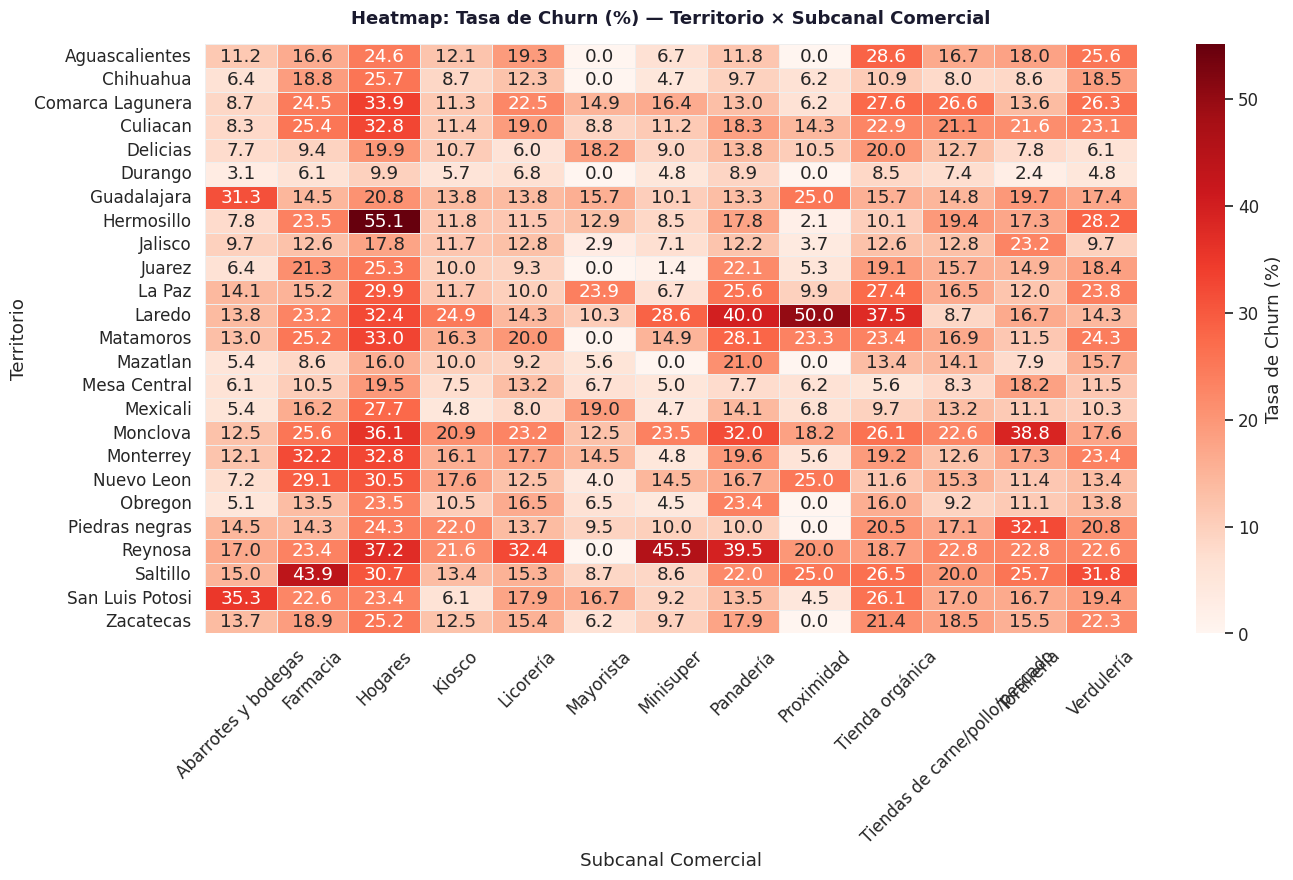

In [23]:
pivot = (
    cust.groupby(["territory", "subchannel"])["target"]
        .mean()
        .unstack(fill_value=0)
        * 100
)
fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(pivot, ax=ax, cmap="Reds", annot=True, fmt=".1f",
            linewidths=0.5, linecolor="#EEEEEE",
            cbar_kws={"label": "Tasa de Churn (%)"})
ax.set_title("Heatmap: Tasa de Churn (%) — Territorio × Subcanal Comercial",
             fontsize=13, fontweight="bold", color=DARK, pad=15)
ax.set_xlabel("Subcanal Comercial"); ax.set_ylabel("Territorio")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
save(fig, "08_heatmap_territorio_subcanal")

## Resumen Estadístico

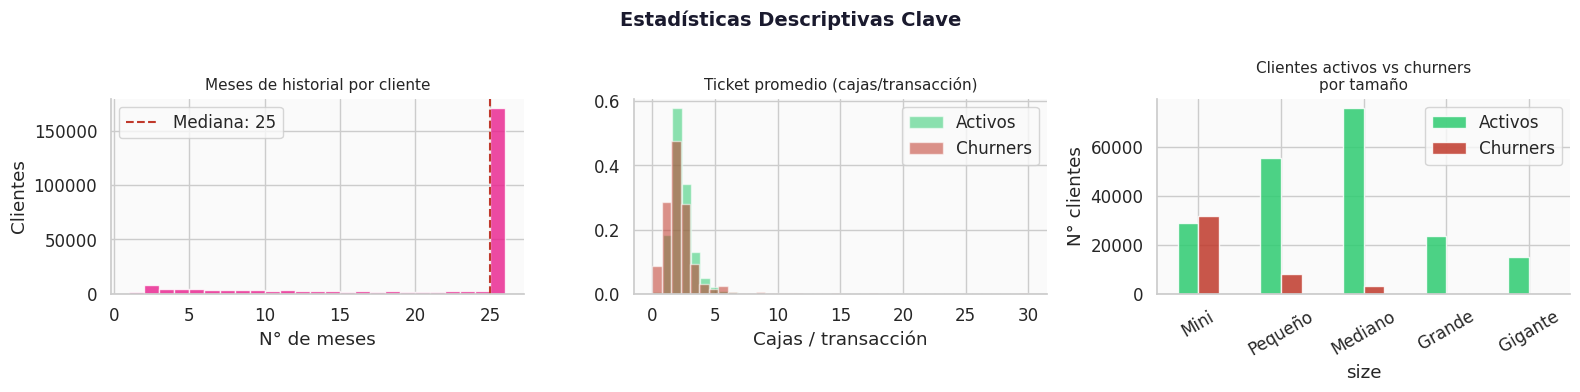

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Estadísticas Descriptivas Clave", fontsize=14, fontweight="bold", color=DARK)

# Meses de historial por cliente
ax = axes[0]
n_meses = cust["n_meses"]
ax.hist(n_meses, bins=range(1, n_meses.max()+2), color=PINK, alpha=0.8, edgecolor="white")
ax.set_title("Meses de historial por cliente", fontsize=11)
ax.set_xlabel("N° de meses"); ax.set_ylabel("Clientes")
ax.axvline(n_meses.median(), color=RED, linestyle="--",
           label=f"Mediana: {n_meses.median():.0f}")
ax.legend()

# Ticket promedio (cajas/txns)
ax = axes[1]
ticket = (cust["mean_cajas"] / (cust["mean_txns"] + 0.1)).clip(0, 30)
for t, label, color in [(0, "Activos", "#2ECC71"), (1, "Churners", RED)]:
    ax.hist(ticket[cust["target"] == t], bins=40, alpha=0.55,
            label=label, color=color, edgecolor="white", density=True)
ax.set_title("Ticket promedio (cajas/transacción)", fontsize=11)
ax.set_xlabel("Cajas / transacción"); ax.legend()

# Clientes por tamaño × churn
ax = axes[2]
size_cross = cust.groupby(["size", "target"]).size().unstack(fill_value=0)
size_cross.columns = ["Activos", "Churners"]
size_cross = size_cross.reindex(["Mini","Pequeño","Mediano","Grande","Gigante","NA"]).dropna()
size_cross.plot(kind="bar", ax=ax, color=["#2ECC71", RED], alpha=0.85,
                edgecolor="white", rot=30)
ax.set_title("Clientes activos vs churners\npor tamaño", fontsize=11)
ax.set_ylabel("N° clientes"); ax.legend()

plt.tight_layout()
save(fig, "09_estadisticas_descriptivas")